<a href="https://www.kaggle.com/code/bavlywaleed/frozenlake-solved-step-by-step-value-iteration?scriptVersionId=305406589" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# 🧊 Dynamic Programming in Action: Escaping the Frozen Lake

---

> *"How does an AI learn to navigate a frozen lake — using pure mathematics, no trial and error?"*

In this notebook, we'll answer that question step by step.

We will use **Dynamic Programming (DP)** — specifically **Value Iteration** — to teach an AI agent to find the perfect path across the Frozen Lake. By the end, you'll deeply understand:

- What Reinforcement Learning is and why it matters
- The **Bellman Equation** (the brain behind DP)
- **Value Iteration**: how an agent builds a "value map" of the world
- **Policy Extraction**: how raw numbers become clear decisions
- How to visualize the agent's journey step-by-step

---

## 📋 Table of Contents
1. [The Problem: What is the Frozen Lake?](#section1)
2. [The Big Picture: What is Reinforcement Learning?](#section2)
3. [The Math: Bellman Equation & Value Iteration](#section3)
4. [Setup: Installing & Importing Libraries](#section4)
5. [Step 1 — Building the Environment](#section5)
6. [Step 2 — Building the Brain (Value Iteration)](#section6)
7. [Step 3 — Extracting the Policy](#section7)
8. [Step 4 — Watching the Agent Solve the Lake](#section8)
9. [Visualizing the Value Map](#section9)
10. [How Values Spread: Iteration by Iteration](#section10)
11. [Key Takeaways & What's Next](#section11)

---
<a id='section1'></a>
## 🧊 Section 1 — The Problem: What is the Frozen Lake?

Imagine you're a little person standing on a **4×4 frozen lake**. Your job: get from the **Start (S)** to the **Goal (G)**. Sounds easy?

The catch? **There are holes (H) in the ice.** Fall in one, and it's game over.

```
┌────┬────┬────┬────┐
│ S  │    │    │    │   S = Start (square 0)
├────┼────┼────┼────┤
│    │ H  │    │ H  │   H = Hole (game over!)
├────┼────┼────┼────┤
│    │    │    │ H  │   G = Goal (you win! 🏆)
├────┼────┼────┼────┤
│ H  │    │    │ G  │
└────┴────┴────┴────┘
     Squares numbered 0–15, left-to-right, top-to-bottom
```

- Square **0**: Start
- Squares **5, 7, 11, 12**: Holes 💀
- Square **15**: Goal 🏆

The agent can move in **4 directions**: Left (0), Down (1), Right (2), Up (3).

Our mission: teach the AI the **optimal policy** — the best action in every single square — so it reaches the Goal every time.

---
<a id='section2'></a>
## 🤖 Section 2 — The Big Picture: What is Reinforcement Learning?

**Reinforcement Learning (RL)** is a type of machine learning where an **agent** learns by interacting with an **environment**.

Think of it like training a dog:
- 🐶 The **dog** = the Agent
- 🏠 The **house** = the Environment
- 🦴 A **treat** = a positive Reward
- 😤 A **scolding** = a negative Reward

The dog learns: *"If I sit when told, I get a treat. If I jump on the sofa, I get scolded."*

In RL terms:

| RL Term | Frozen Lake Meaning |
|---|---|
| **Agent** | The person walking on the ice |
| **Environment** | The 4×4 frozen lake grid |
| **State** | Which square the agent currently stands on |
| **Action** | Moving Left, Down, Right, or Up |
| **Reward** | +1 for reaching Goal, 0 everywhere else |
| **Policy** | The rulebook: *"In state X, do action Y"* |

### 🎯 Two Ways to Learn in RL

| Approach | How It Works | Example |
|---|---|---|
| **Model-Free** (Learning) | Agent tries, fails, and learns from experience | Q-Learning, PPO |
| **Model-Based** (Planning) | Agent uses a full model to plan ahead mathematically | **Dynamic Programming** ← *This notebook!* |

**Dynamic Programming** is special: the agent **doesn't explore at all** — it already has the full transition model and computes the perfect strategy through math alone.

---
<a id='section3'></a>
## 🧮 Section 3 — The Math: Bellman Equation & Value Iteration

### What is a "Value"?

The **Value V(s)** of a state `s` is the **expected total future reward** the agent can collect from that state, following the best possible strategy.

Think of it as a **price tag** on each square:
- Square 14 (next to Goal): High value — one step away from reward!
- Squares 5, 7, 11, 12 (Holes): Value = 0 — game ends here.
- Square 0 (Start): Lower value — many steps from reward.

### The Bellman Optimality Equation

$$V(s) = \max_{a} \sum_{s'} P(s'|s,a) \cdot [R(s,a,s') + \gamma \cdot V(s')]$$

In plain English:
> *"The value of a square = the best action available, where each action is scored by: (immediate reward) + (discounted value of the next square)"*

| Symbol | Meaning |
|---|---|
| `V(s)` | Value of current state `s` |
| `a` | A possible action |
| `P(s'\|s,a)` | Probability of reaching `s'` from `s` via action `a` |
| `R(s,a,s')` | Immediate reward received |
| `γ` (gamma) | **Discount factor** (0 to 1): patience for future rewards |
| `V(s')` | Value of the next state `s'` |

### The Discount Factor γ

| γ value | Behavior |
|---|---|
| γ = 0 | Completely impatient — only cares about immediate reward |
| γ = 0.99 | Mostly patient — slightly prefers shorter paths ← *our setting* |
| γ = 1 | Infinitely patient — treats future rewards equally |

### Manual Trace: 3 Sweeps

**Start**: V = [0, 0, 0, ..., 0] (all 16 squares at zero)

**Sweep 1** — The first spark of knowledge:
- All squares see no reward → stay 0
- **Square 14** moves Right → Goal (+1 reward!)
- Bellman: `1 + (0.99 × 0) = 1.0` → **V[14] = 1.0**

**Sweep 2** — Reward starts spreading:
- **Square 13** moves Right → Square 14 (value=1.0): `0 + 0.99×1.0 = 0.99` → **V[13] = 0.99**
- **Square 10** moves Down → Square 14: `0 + 0.99×1.0 = 0.99` → **V[10] = 0.99**

**Sweep 3** — The wave goes further:
- **Square 9** moves Right → Square 10 (value=0.99): `0 + 0.99×0.99 = 0.9801` → **V[9] = 0.98**
- **Square 6** moves Down → Square 10: same result → **V[6] = 0.98**

**The pattern**: Value waves propagate **backwards from the Goal**, reaching the Start after ~6 sweeps. Then fine-tuning continues until convergence!

---
<a id='section4'></a>
## ⚙️ Section 4 — Setup: Installing & Importing Libraries

In [1]:
# Install Gymnasium (OpenAI's RL environment toolkit)
# The [toy_text] extra includes the FrozenLake environment
!pip install gymnasium[toy_text] --quiet

In [2]:
import numpy as np                        # Numerical arrays and math
import gymnasium as gym                  # RL environments
import matplotlib.pyplot as plt          # Visualization
import matplotlib.patches as mpatches
from IPython.display import clear_output # For animation
import time
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")
print(f"   NumPy version:      {np.__version__}")
print(f"   Gymnasium version:  {gym.__version__}")

✅ All libraries imported successfully!
   NumPy version:      2.0.2
   Gymnasium version:  1.2.0


---
<a id='section5'></a>
## 🏗️ Section 5 — Step 1: Building the Environment

Key parameters explained:

| Parameter | Value | Meaning |
|---|---|---|
| `map_name` | `"4x4"` | 4×4 grid = 16 squares |
| `is_slippery` | `False` | **Deterministic**: move Right → go Right (100%). Set True for random ice physics! |
| `render_mode` | `"rgb_array"` | Returns pixel images → enables animation |

`env.unwrapped.P[s][a]` is the agent's **transition catalog** — the perfect model of the world used for planning.

In [3]:
# Create the FrozenLake environment
env = gym.make(
    'FrozenLake-v1',
    desc=None,
    map_name="4x4",
    is_slippery=False,   # Deterministic — perfect for Dynamic Programming!
    render_mode="rgb_array"
)

n_states  = env.observation_space.n   # 16 squares
n_actions = env.action_space.n        # 4 directions

print(f"🗺️  Environment created!")
print(f"   States  (squares): {n_states}")
print(f"   Actions           : {n_actions}  →  0=Left, 1=Down, 2=Right, 3=Up")
print()

# Peek at the transition model for one square + action
print("📖 Example: What happens from Square 14 if we move Right (action=2)?")
for prob, next_state, reward, done in env.unwrapped.P[14][2]:
    print(f"   prob={prob:.1f} | next_state={next_state} | reward={reward} | done={done}")
print("   → We reach square 15 (Goal) with reward +1!  ✅")

🗺️  Environment created!
   States  (squares): 16
   Actions           : 4  →  0=Left, 1=Down, 2=Right, 3=Up

📖 Example: What happens from Square 14 if we move Right (action=2)?
   prob=1.0 | next_state=15 | reward=1.0 | done=True
   → We reach square 15 (Goal) with reward +1!  ✅


---
<a id='section6'></a>
## 🧠 Section 6 — Step 2: Building the Brain (Value Iteration)

This is the heart of the algorithm. The pseudocode:

```
Initialize: V[s] = 0 for all states
Repeat until convergence:
    For each state s:
        For each action a:
            Compute expected value using Bellman equation
        V[s] = max over all actions  (greedy/optimal)
    If max change this sweep < threshold: STOP
```

The `env.unwrapped.P[s][a]` catalog returns:
- `prob`: transition probability (1.0 in our deterministic world)
- `next_state`: where we land
- `reward`: immediate reward
- `done`: episode ends (Goal or Hole)

In [4]:
# ══════════════════════════════════════════════
# VALUE ITERATION
# ══════════════════════════════════════════════

# Initialize: empty brain (all values = 0)
V = np.zeros(n_states)

gamma     = 0.99   # Discount factor: how much we value future vs. immediate rewards
threshold = 1e-4   # Stop when values change by less than this amount

sweep_count = 0
history     = [V.copy()]  # Track history for visualization

print("🧮 Running Value Iteration...")
print(f"   γ (gamma) = {gamma}  |  threshold = {threshold}")
print()
print(f"   {'Sweep':>6}  {'Max Δ':>12}  {'V[14]':>8}  {'V[10]':>8}  {'V[0]':>8}")
print("   " + "-"*54)

while True:
    delta = 0

    for s in range(n_states):       # Visit every square
        v_old = V[s]

        action_values = np.zeros(n_actions)

        for a in range(n_actions):  # Try every action (in imagination only)
            for prob, next_state, reward, done in env.unwrapped.P[s][a]:
                # ── BELLMAN EQUATION ──────────────────────────
                # value(action) += prob × (reward + γ × value(next_state))
                action_values[a] += prob * (reward + gamma * V[next_state])

        # Greedy selection: take the maximum value across all actions
        V[s] = np.max(action_values)

        # Track the largest value change this sweep
        delta = max(delta, abs(v_old - V[s]))

    sweep_count += 1
    history.append(V.copy())

    if sweep_count <= 8 or delta < threshold:
        marker = " ← CONVERGED ✅" if delta < threshold else ""
        print(f"   {sweep_count:>6}  {delta:>12.6f}  {V[14]:>8.4f}  {V[10]:>8.4f}  {V[0]:>8.4f}{marker}")

    if delta < threshold:
        break

print()
print(f"✅ Converged in {sweep_count} sweeps!")
print()
print("📊 Final Value Table (4×4 grid):")
print(np.round(V.reshape(4, 4), 4))

🧮 Running Value Iteration...
   γ (gamma) = 0.99  |  threshold = 0.0001

    Sweep         Max Δ     V[14]     V[10]      V[0]
   ------------------------------------------------------
        1      1.000000    1.0000    0.0000    0.0000
        2      0.990000    1.0000    0.9900    0.0000
        3      0.980100    1.0000    0.9900    0.0000
        4      0.970299    1.0000    0.9900    0.0000
        5      0.960596    1.0000    0.9900    0.0000
        6      0.950990    1.0000    0.9900    0.9510
        7      0.000000    1.0000    0.9900    0.9510 ← CONVERGED ✅

✅ Converged in 7 sweeps!

📊 Final Value Table (4×4 grid):
[[0.951  0.9606 0.9703 0.9606]
 [0.9606 0.     0.9801 0.    ]
 [0.9703 0.9801 0.99   0.    ]
 [0.     0.99   1.     0.    ]]


---
<a id='section7'></a>
## 🗺️ Section 7 — Step 3: Extracting the Policy

Now we convert the **value table** into **action instructions**.

The logic: for each square, try all 4 actions imaginarily, compute where each leads, and pick the action leading to the **highest-value next state**.

- Value Iteration: saves `max(values)` → **what's the best achievable?**
- Policy Extraction: saves `argmax(values)` → **which action achieves it?**

In [5]:
# ══════════════════════════════════════════════
# POLICY EXTRACTION
# ══════════════════════════════════════════════

policy = np.zeros(n_states, dtype=int)

for s in range(n_states):
    action_values = np.zeros(n_actions)
    for a in range(n_actions):
        for prob, next_state, reward, done in env.unwrapped.P[s][a]:
            action_values[a] += prob * (reward + gamma * V[next_state])
    policy[s] = np.argmax(action_values)  # Action with highest expected value

# Readable symbols
arrows = {0: '←', 1: '↓', 2: '→', 3: '↑'}
names  = {0: 'Left', 1: 'Down', 2: 'Right', 3: 'Up'}

holes = {5, 7, 11, 12}
goal  = {15}

print("✅ Policy extracted!")
print()
print("🗺️  Optimal Policy (4×4 grid):")
for row in range(4):
    row_str = "   "
    for col in range(4):
        s = row * 4 + col
        if s in holes:    row_str += " H  "
        elif s in goal:   row_str += " G  "
        elif s == 0:      row_str += " S  "
        else:             row_str += f" {arrows[policy[s]]}  "
    print(row_str)

print()
print("📋 Per-square instructions:")
for s in range(n_states):
    if s not in holes and s not in goal:
        tag = "(Start)" if s == 0 else ""
        print(f"   Square {s:2d} {tag:<7}: {arrows[policy[s]]}  ({names[policy[s]]})  [V={V[s]:.4f}]")

✅ Policy extracted!

🗺️  Optimal Policy (4×4 grid):
    S   →   ↓   ←  
    ↓   H   ↓   H  
    →   ↓   ↓   H  
    H   →   →   G  

📋 Per-square instructions:
   Square  0 (Start): ↓  (Down)  [V=0.9510]
   Square  1        : →  (Right)  [V=0.9606]
   Square  2        : ↓  (Down)  [V=0.9703]
   Square  3        : ←  (Left)  [V=0.9606]
   Square  4        : ↓  (Down)  [V=0.9606]
   Square  6        : ↓  (Down)  [V=0.9801]
   Square  8        : →  (Right)  [V=0.9703]
   Square  9        : ↓  (Down)  [V=0.9801]
   Square 10        : ↓  (Down)  [V=0.9900]
   Square 13        : →  (Right)  [V=0.9900]
   Square 14        : →  (Right)  [V=1.0000]


---
<a id='section8'></a>
## 🎬 Section 8 — Step 4: Watching the Agent Solve the Lake

The brain is ready! Now the agent **actually walks** the lake using the computed policy.

At each step:
1. Render the current frame
2. Ask the policy: *"I'm at square X — what do I do?"*
3. Execute that action
4. Repeat until done

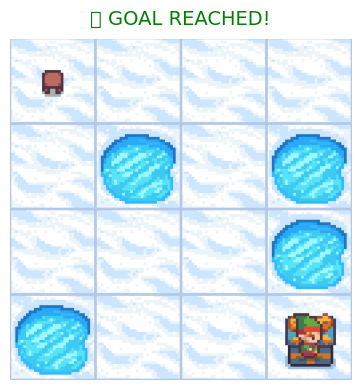


🏆 Success! Goal reached in 6 steps.
   Path: 0 → 4 → 8 → 9 → 13 → 14 → 15


In [6]:
# ══════════════════════════════════════════════
# EXECUTION & ANIMATION
# ══════════════════════════════════════════════

state, _ = env.reset()
done  = False
step  = 0
path  = [state]

print("🎬 Agent starting journey...")
print()

while not done:
    frame = env.render()

    clear_output(wait=True)
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(frame)
    ax.axis('off')
    ax.set_title(
        f'Step {step} | Square {state} | {arrows[policy[state]]} {names[policy[state]]}',
        fontsize=12, pad=8
    )
    plt.tight_layout()
    plt.show()

    action = policy[state]
    next_state, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated

    print(f"   Step {step}: Square {state:2d}  →  {arrows[action]} {names[action]:<5}  →  Square {next_state:2d}")

    state = next_state
    path.append(state)
    step += 1
    time.sleep(0.5)

# Final frame
frame = env.render()
clear_output(wait=True)
fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(frame)
ax.axis('off')
result = "🏆 GOAL REACHED!" if reward == 1.0 else "💀 Fell in a Hole!"
color  = "green" if reward == 1.0 else "red"
ax.set_title(result, fontsize=14, color=color, pad=10)
plt.tight_layout()
plt.show()

print()
print("=" * 45)
if reward == 1.0:
    print(f"🏆 Success! Goal reached in {step} steps.")
    print(f"   Path: {' → '.join(map(str, path))}")
else:
    print("💀 Fell in a Hole!")
print("=" * 45)
env.close()

---
<a id='section9'></a>
## 📊 Section 9 — Visualizing the Value Map

Numbers in a table are informative — but a heatmap tells the story instantly.

- **Brighter / warmer color** = Higher value (closer to Goal via optimal path)
- **Dark** = Low or zero value (far from Goal, or Holes)
- Notice: the Holes are all 0 — the agent treats them as dead ends
- The bright "highway" traces the optimal route!

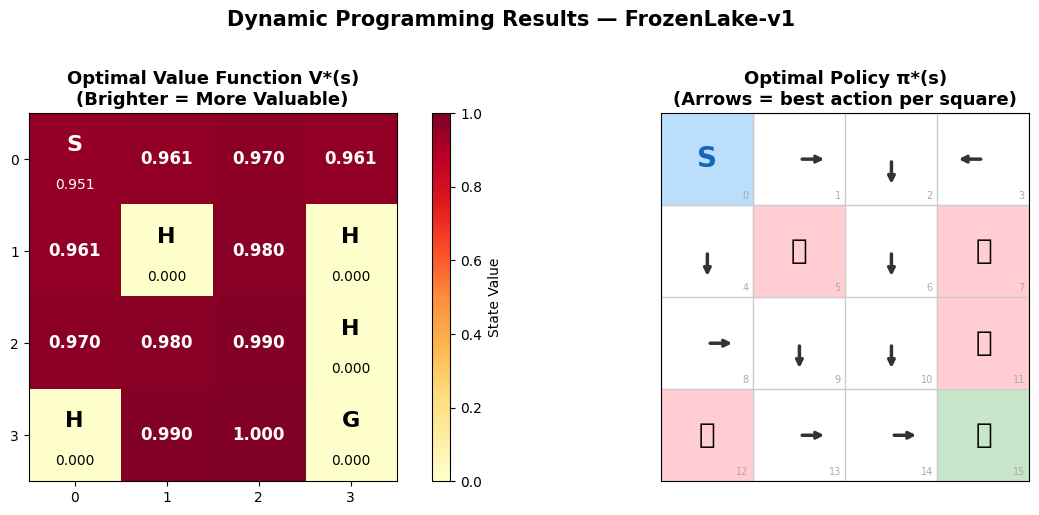

📊 Saved: frozen_lake_results.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left plot: Value Heatmap ────────────────────────────────────────────────
ax = axes[0]
V_grid = V.reshape(4, 4)
im = ax.imshow(V_grid, cmap='YlOrRd', aspect='equal', vmin=0, vmax=1)

special = {0: 'S', 5: 'H', 7: 'H', 11: 'H', 12: 'H', 15: 'G'}

for row in range(4):
    for col in range(4):
        s   = row * 4 + col
        val = V_grid[row, col]
        txt_color = 'white' if val > 0.5 else 'black'
        if s in special:
            ax.text(col, row - 0.15, special[s], ha='center', va='center',
                    fontsize=16, fontweight='bold', color=txt_color)
            ax.text(col, row + 0.28, f"{val:.3f}", ha='center', va='center',
                    fontsize=10, color=txt_color)
        else:
            ax.text(col, row, f"{val:.3f}", ha='center', va='center',
                    fontsize=12, fontweight='bold', color=txt_color)

ax.set_xticks(range(4)); ax.set_yticks(range(4))
ax.set_title('Optimal Value Function V*(s)\n(Brighter = More Valuable)', fontsize=13, fontweight='bold')
plt.colorbar(im, ax=ax, label='State Value')

# ── Right plot: Policy Arrow Map ────────────────────────────────────────────
ax2 = axes[1]
ax2.set_xlim(-0.5, 3.5); ax2.set_ylim(3.5, -0.5)
ax2.set_aspect('equal')

dx = {0: -0.3, 1: 0,    2: 0.3,  3: 0}
dy = {0: 0,    1: 0.3,  2: 0,    3: -0.3}

for row in range(4):
    for col in range(4):
        s = row * 4 + col
        a = policy[s]

        if s == 0:
            ax2.add_patch(plt.Rectangle((col-.5, row-.5), 1, 1, color='#BBDEFB', zorder=0))
            ax2.text(col, row, 'S', ha='center', va='center',
                     fontsize=20, fontweight='bold', color='#1565C0')
        elif s == 15:
            ax2.add_patch(plt.Rectangle((col-.5, row-.5), 1, 1, color='#C8E6C9', zorder=0))
            ax2.text(col, row, '🏆', ha='center', va='center', fontsize=20)
        elif s in {5, 7, 11, 12}:
            ax2.add_patch(plt.Rectangle((col-.5, row-.5), 1, 1, color='#FFCDD2', zorder=0))
            ax2.text(col, row, '💀', ha='center', va='center', fontsize=20)
        else:
            ax2.annotate('', xy=(col + dx[a], row + dy[a]), xytext=(col, row),
                         arrowprops=dict(arrowstyle='->', color='#333', lw=2.5))

        ax2.text(col + 0.45, row + 0.45, str(s), ha='right', va='bottom',
                 fontsize=7, color='#aaa')

for i in range(5):
    ax2.axhline(i - 0.5, color='#ccc', lw=1)
    ax2.axvline(i - 0.5, color='#ccc', lw=1)

ax2.set_xticks([]); ax2.set_yticks([])
ax2.set_title('Optimal Policy π*(s)\n(Arrows = best action per square)', fontsize=13, fontweight='bold')

plt.suptitle('Dynamic Programming Results — FrozenLake-v1',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('frozen_lake_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Saved: frozen_lake_results.png")

---
<a id='section10'></a>
## 🌊 Section 10 — How Values Spread: Iteration by Iteration

Let's make the value wave *visible*. The grid below shows the value map at different sweeps.

Watch how reward knowledge radiates **backwards from the Goal** — like sonar pinging back information about where safety lies.

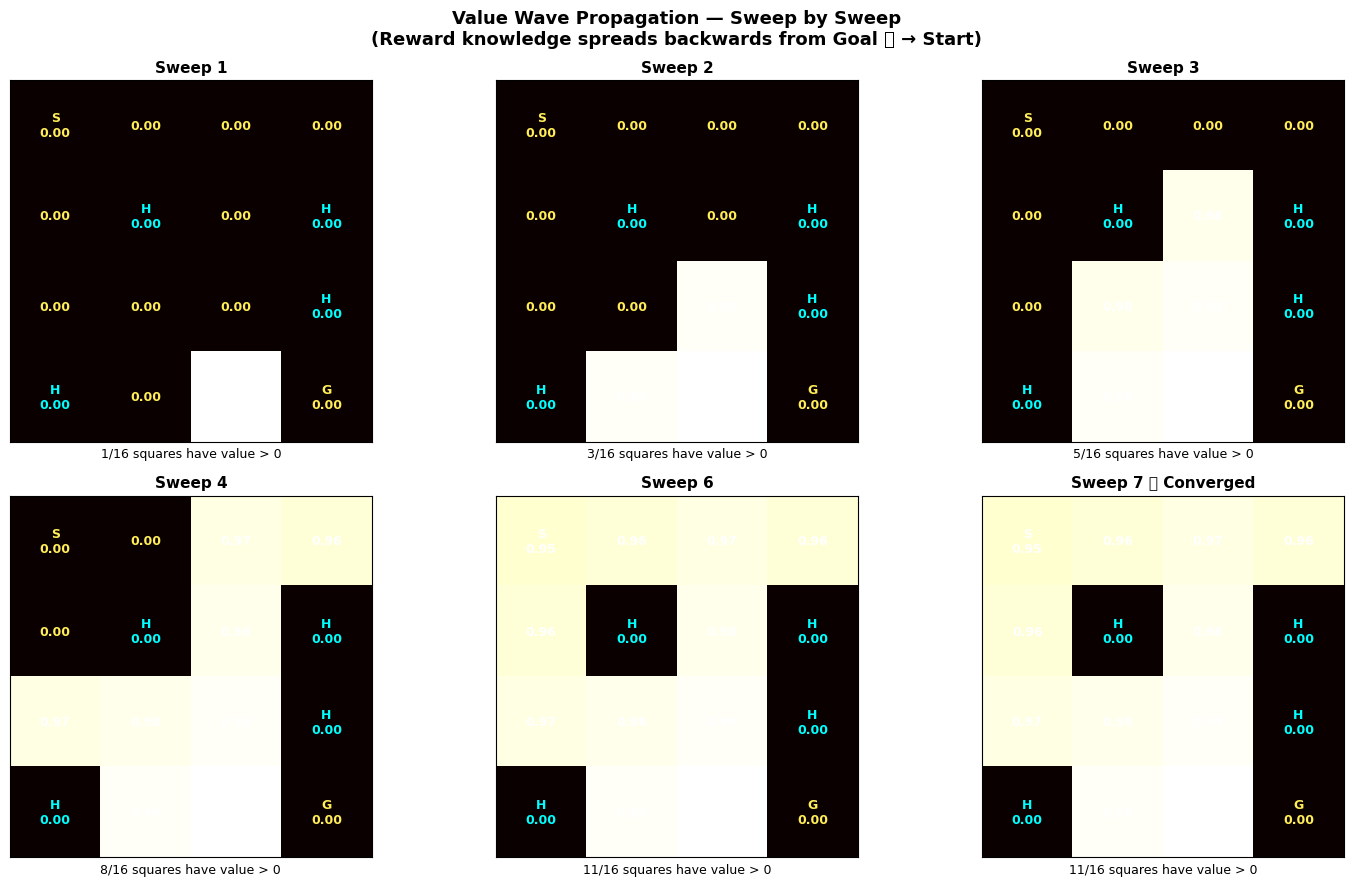

📊 Saved: value_propagation.png


In [8]:
# Snapshot grid at key sweeps
key_sweeps = [1, 2, 3, 4, 6, len(history)-1]
key_sweeps = sorted(set(min(i, len(history)-1) for i in key_sweeps))

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for idx, sw in enumerate(key_sweeps):
    ax = axes[idx]
    V_snap = history[sw].reshape(4, 4)
    im = ax.imshow(V_snap, cmap='hot', aspect='equal', vmin=0, vmax=1)

    for row in range(4):
        for col in range(4):
            s   = row * 4 + col
            val = V_snap[row, col]
            c   = 'white' if val > 0.4 else '#FFEE58'

            if s == 0:    lbl = f"S\n{val:.2f}"
            elif s == 15: lbl = f"G\n{val:.2f}"
            elif s in {5,7,11,12}: lbl = f"H\n{val:.2f}"; c = 'cyan'
            else:         lbl = f"{val:.2f}"

            ax.text(col, row, lbl, ha='center', va='center',
                    fontsize=9, fontweight='bold', color=c)

    is_done = sw == len(history) - 1
    title   = f"Sweep {sw}" + (" ✅ Converged" if is_done else "")
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])
    nz = int(np.sum(history[sw] > 0.001))
    ax.set_xlabel(f"{nz}/16 squares have value > 0", fontsize=9)

fig.suptitle('Value Wave Propagation — Sweep by Sweep\n'
             '(Reward knowledge spreads backwards from Goal 🏆 → Start)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('value_propagation.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Saved: value_propagation.png")

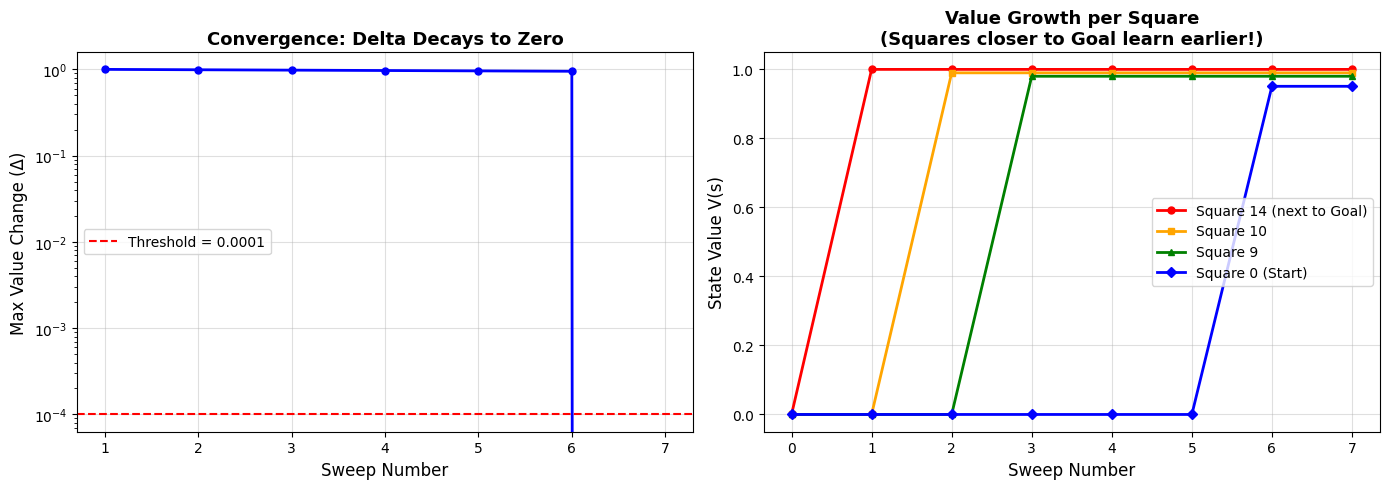

📊 Saved: convergence.png


In [9]:
# Convergence plot
deltas = [np.max(np.abs(history[i] - history[i-1])) for i in range(1, len(history))]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: delta decay
ax = axes[0]
ax.plot(range(1, len(deltas)+1), deltas, 'b-o', markersize=5, linewidth=2)
ax.axhline(y=threshold, color='red', linestyle='--', linewidth=1.5, label=f'Threshold = {threshold}')
ax.set_xlabel('Sweep Number', fontsize=12)
ax.set_ylabel('Max Value Change (Δ)', fontsize=12)
ax.set_title('Convergence: Delta Decays to Zero', fontsize=13, fontweight='bold')
ax.set_yscale('log')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.4)

# Right: individual square values growing
ax2 = axes[1]
ax2.plot([h[14] for h in history], 'r-o',  ms=5, lw=2, label='Square 14 (next to Goal)')
ax2.plot([h[10] for h in history], color='orange', marker='s', ms=5, lw=2, label='Square 10')
ax2.plot([h[9]  for h in history], 'g-^',  ms=5, lw=2, label='Square 9')
ax2.plot([h[0]  for h in history], 'b-D',  ms=5, lw=2, label='Square 0 (Start)')
ax2.set_xlabel('Sweep Number', fontsize=12)
ax2.set_ylabel('State Value V(s)', fontsize=12)
ax2.set_title('Value Growth per Square\n(Squares closer to Goal learn earlier!)', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('convergence.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Saved: convergence.png")

---
<a id='section11'></a>
## 🎓 Section 11 — Key Takeaways & What's Next

### 🔑 Summary

| Concept | Core Idea |
|---|---|
| **Value Function V(s)** | A "price tag" per state — total expected future reward from there |
| **Bellman Equation** | Recursively links a state's value to its neighbors |
| **Value Iteration** | Repeatedly apply Bellman updates until values stabilize |
| **Policy Extraction** | Once stable, optimal action = argmax over action values |
| **Discount Factor γ** | Patience knob — near 1 means "prefer shorter paths slightly" |
| **Convergence** | Guaranteed to find the mathematically optimal solution |

### 💡 When Does DP Work?

DP is the right tool when:
1. ✅ The environment model is **fully known** (we have transition probabilities)
2. ✅ The state space is **small enough** to enumerate
3. ✅ The reward structure is **clear and stable**

In real-world problems (huge/unknown environments), we need other approaches...

### 🚀 What's Next?

| Algorithm | Key Idea | When to Use |
|---|---|---|
| **Policy Iteration** | Alternate eval & improvement — faster than VI | Still model-based, small spaces |
| **Q-Learning** | Learn from trial & error — no model needed | Unknown environment |
| **DQN (Deep Q-Network)** | Neural net approximates Q-function | Large/continuous state spaces |
| **PPO / A3C** | Policy gradient — directly optimize the policy | Complex, continuous action spaces |

### 🧩 Experiments to Try

1. **Change γ**: Set `gamma = 0.5` — how does the value map change? Does the agent still succeed?
2. **Slippery ice**: Set `is_slippery=True` — now P has probabilities < 1. Does DP still work?
3. **Bigger lake**: Try `map_name="8x8"` — 64 states. How many sweeps to converge?
4. **Custom map**: Use the `desc` parameter to design your own frozen lake!

### 📚 Further Reading

- 📖 [Sutton & Barto — RL: An Introduction](http://incompleteideas.net/book/the-book-2nd.html) — The RL bible (free!)
- 📖 [Gymnasium Documentation](https://gymnasium.farama.org/) — All RL environments
- 📖 [David Silver's RL Course](https://www.davidsilver.uk/teaching/) — Best free video lectures

---

*If this notebook helped you, please give it an upvote ⬆️ — it helps others find it. Happy learning! 🙏*